Gen 20: ⚠️ Гіпермутація 50.0%
Gen 21: ⚠️ Гіпермутація 50.0%
Gen 22: ⚠️ Гіпермутація 50.0%
Gen 23: ⚠️ Гіпермутація 50.0%
Gen 24: ⚠️ Гіпермутація 50.0%
Gen 25: ⚠️ Гіпермутація 50.0%
Gen 26: ⚠️ Гіпермутація 50.0%
Gen 27: ⚠️ Гіпермутація 50.0%
Gen 28: ⚠️ Гіпермутація 50.0%
Gen 29: ⚠️ Гіпермутація 50.0%
Gen 30: ✅ Повернення до норми


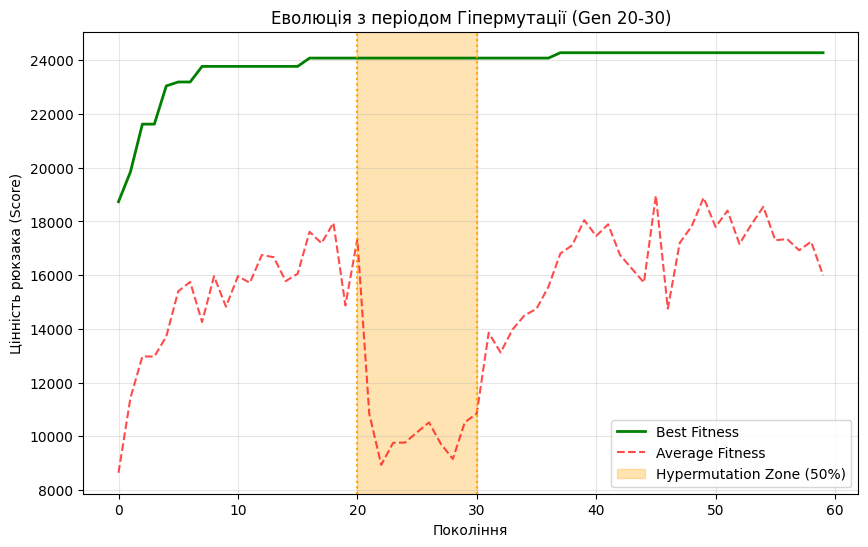

Найкращий результат: 24281.550000000003


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Вхідні дані (Товари) ---
products_data = [
    ('Refrigerator A', 0.751, 999.90),
    ('Cell phone', 0.00000899, 2199.12),
    ('TV 55', 0.400, 4346.99),
    ("TV 50'", 0.290, 3999.90),
    ("TV 42'", 0.200, 2999.00),
    ("Notebook A", 0.00350, 2499.90),
    ("Ventilator", 0.496, 199.90),
    ("Microwave A", 0.0424, 308.66),
    ("Microwave B", 0.0544, 429.90),
    ("Microwave C", 0.0319, 299.29),
    ("Refrigerator B", 0.635, 849.00),
    ("Refrigerator C", 0.870, 1199.89),
    ("Notebook B", 0.498, 1999.90),
    ("Notebook C", 0.527, 3999.00)
]

spaces = [p[1] for p in products_data]
prices = [p[2] for p in products_data]
limit = 3.0

# --- 2. Клас Особини (Individual) ---
class Individual:
    def __init__(self, spaces, prices, space_limit):
        self.spaces = spaces
        self.prices = prices
        self.space_limit = space_limit
        self.score_evaluation = 0
        self.used_space = 0
        self.chromosome = []
        
        # Ініціалізація
        for _ in range(len(spaces)):
            self.chromosome.append('1' if random.random() < 0.5 else '0')

    def fitness(self):
        score = 0
        sum_spaces = 0
        for i in range(len(self.chromosome)):
            if self.chromosome[i] == '1':
                score += self.prices[i]
                sum_spaces += self.spaces[i]
        
        # Жорсткий штраф: якщо перевищили, фітнес = 1
        if sum_spaces > self.space_limit:
            score = 1 
        
        self.score_evaluation = score
        self.used_space = sum_spaces

    # --- Мутація (Flip Bit) ---
    def mutation(self, rate):
        for i in range(len(self.chromosome)):
            if random.random() < rate:
                self.chromosome[i] = '1' if self.chromosome[i] == '0' else '0'

    # --- Кросовер (Uniform) ---
    def crossover(self, other):
        child1_chrom, child2_chrom = [], []
        for i in range(len(self.chromosome)):
            if random.random() < 0.5:
                child1_chrom.append(self.chromosome[i])
                child2_chrom.append(other.chromosome[i])
            else:
                child1_chrom.append(other.chromosome[i])
                child2_chrom.append(self.chromosome[i])
        
        children = [Individual(self.spaces, self.prices, self.space_limit),
                    Individual(self.spaces, self.prices, self.space_limit)]
        children[0].chromosome = child1_chrom
        children[1].chromosome = child2_chrom
        return children

# --- 3. Клас Генетичного Алгоритму (Модифікований) ---
class GeneticAlgorithmCustom:
    def __init__(self, population_size):
        self.population_size = population_size
        self.population = []
        
    def initialize_population(self, spaces, prices, space_limit):
        self.population = [Individual(spaces, prices, space_limit) for _ in range(self.population_size)]

    def solve_with_catastrophe(self, base_mutation_rate, num_generations, spaces, prices, limit):
        self.initialize_population(spaces, prices, limit)
        
        # Для графіків
        history_best = []
        history_avg = []
        
        for generation in range(num_generations):
            # 1. Оцінка популяції
            for ind in self.population: 
                ind.fitness()
            
            # Сортуємо (найкращі зверху)
            self.population.sort(key=lambda x: x.score_evaluation, reverse=True)
            
            # Збираємо статистику
            best_score = self.population[0].score_evaluation
            avg_score = sum(ind.score_evaluation for ind in self.population) / self.population_size
            history_best.append(best_score)
            history_avg.append(avg_score)
            
            # --- ЛОГІКА КАТАСТРОФИ ---
            current_mutation = base_mutation_rate
            
            if 20 <= generation < 30:
                current_mutation = 0.50  # 50% мутація!
                # Опціонально: можна вимкнути елітизм, щоб підсилити ефект
                # Але тут залишимо елітизм, щоб побачити, чи виживе найкращий
                print(f"Gen {generation}: ⚠️ Гіпермутація {current_mutation*100}%")
            elif generation == 30:
                print(f"Gen {generation}: ✅ Повернення до норми")

            # 2. Селекція та Нова Популяція
            # Елітизм: переносимо 2 найкращих без змін (вони переживуть катастрофу, якщо не змінити логіку)
            # Якщо хочете "повний хаос", можна закоментувати ці рядки в період катастрофи
            new_population = [self.population[0], self.population[1]]
            
            # Для решти - рулетка або турнір. Тут проста рулетка.
            total_fitness = sum(ind.score_evaluation for ind in self.population)
            
            while len(new_population) < self.population_size:
                # Вибір батьків
                parent1 = self.roulette_select(total_fitness)
                parent2 = self.roulette_select(total_fitness)
                
                # Кросовер
                children = parent1.crossover(parent2)
                
                # Мутація (з динамічним шансом!)
                for child in children:
                    child.mutation(current_mutation)
                    new_population.append(child)
                    if len(new_population) >= self.population_size:
                        break
            
            self.population = new_population

        return self.population[0], history_best, history_avg

    def roulette_select(self, total_fitness):
        r = random.uniform(0, total_fitness)
        current_sum = 0
        for ind in self.population:
            current_sum += ind.score_evaluation
            if current_sum >= r:
                return ind
        return self.population[0]

# --- 4. Запуск Експерименту ---
ga = GeneticAlgorithmCustom(population_size=50) # Більша популяція для стабільності
best_solution, hist_best, hist_avg = ga.solve_with_catastrophe(
    base_mutation_rate=0.05,  # 5% звичайна мутація
    num_generations=60, 
    spaces=spaces, 
    prices=prices, 
    limit=limit
)

# --- 5. Візуалізація ---
plt.figure(figsize=(10, 6))
plt.plot(hist_best, label='Best Fitness', color='green', linewidth=2)
plt.plot(hist_avg, label='Average Fitness', color='red', linestyle='--', alpha=0.7)

# Додаємо зону катастрофи
plt.axvspan(20, 30, color='orange', alpha=0.3, label='Hypermutation Zone (50%)')
plt.axvline(x=20, color='orange', linestyle=':')
plt.axvline(x=30, color='orange', linestyle=':')

plt.title('Еволюція з періодом Гіпермутації (Gen 20-30)')
plt.xlabel('Покоління')
plt.ylabel('Цінність рюкзака (Score)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Найкращий результат: {best_solution.score_evaluation}")